# Neural-state energy analysis

This standalone notebook reproduces the neural-state energy comparison for all controller constraints and angles.

## Setup and reproducibility

Run this notebook from the directory containing the controller output folders. The analysis is deterministic and records package versions. Figures are displayed inline and are not saved.

In [1]:
from pathlib import Path
import platform

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

random_seed = 0
np.random.seed(random_seed)

runtime_versions = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "matplotlib": matplotlib.__version__,
}
runtime_versions

{'python': '3.13.3', 'numpy': '2.2.5', 'matplotlib': '3.10.1'}

## Data configuration

Set `data_root` to the directory containing `data_overlapping`, `data_orthogonal`, and `data_recurrence`. Set `w_type` to `non_normal` or `oscillatory`. Conditions 1, 2, and 3 correspond to $\pi/8$, $\pi/4$, and $3\pi/8$.

In [2]:
data_root = Path(".")
w_types = ("non_normal", "oscillatory")
w_type = "oscillatory"
controller_types = ("overlapping", "orthogonal", "recurrence")
angle_indices = (1, 2, 3)
angle_labels = {1: "π/8", 2: "π/4", 3: "3π/8"}
controller_labels = {
    "overlapping": "Overlapping-constrained",
    "orthogonal": "Orthogonal-constrained",
    "recurrence": "Recurrence-constrained",
}
controller_paths = {
    "overlapping": ("data_overlapping", "overlapping"),
    "orthogonal": ("data_orthogonal", "orthogonal"),
    "recurrence": ("data_recurrence", "recurrence"),
}

if w_type not in w_types:
    raise ValueError("w_type must be non_normal or oscillatory")

## Load and validate neural-state trajectories

Each controller-angle condition must contain a two-dimensional neural-state trajectory.

In [3]:
def neural_state_path(controller_name, condition_index):
    directory_name, file_label = controller_paths[controller_name]
    return data_root / directory_name / w_type / f"ss_{file_label}_{condition_index}.npy"


def load_neural_states():
    dataset = {}
    missing = []
    for controller_name in controller_types:
        for condition_index in angle_indices:
            path = neural_state_path(controller_name, condition_index)
            if not path.exists():
                missing.append(str(path))
                continue
            values = np.load(path)
            if values.ndim != 2 or values.shape[1] != 2:
                raise ValueError(f"invalid neural-state shape for {controller_name}, condition {condition_index}: {values.shape}")
            dataset[(controller_name, condition_index)] = values
    if missing:
        raise FileNotFoundError("missing analysis inputs:\n" + "\n".join(missing))
    return dataset


data = load_neural_states()
print(f"loaded {len(data)} controller-angle conditions for {w_type}")

loaded 9 controller-angle conditions for oscillatory


## Energy across conditions

Network energy is the sum of squared neural-state activity over all time samples and both neural dimensions. The first plot compares individual angle conditions; the second summarizes controller means with individual conditions overlaid.

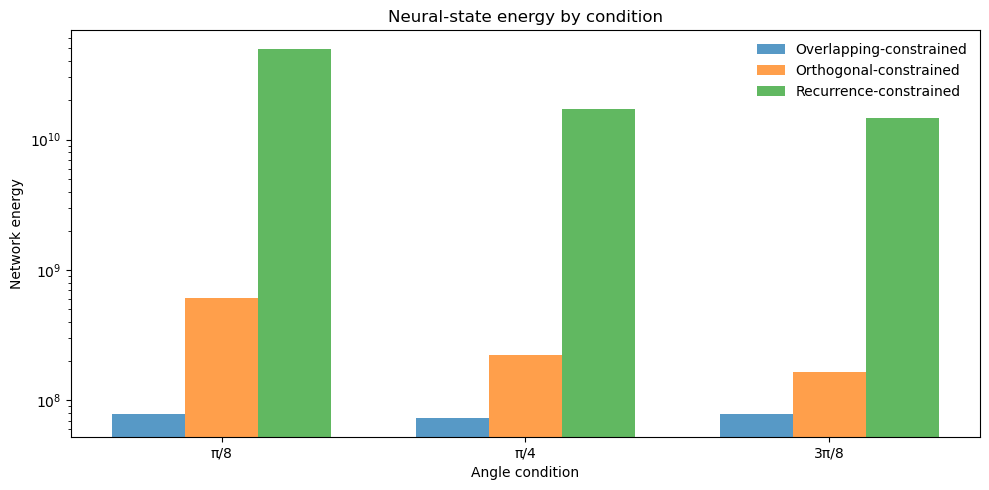

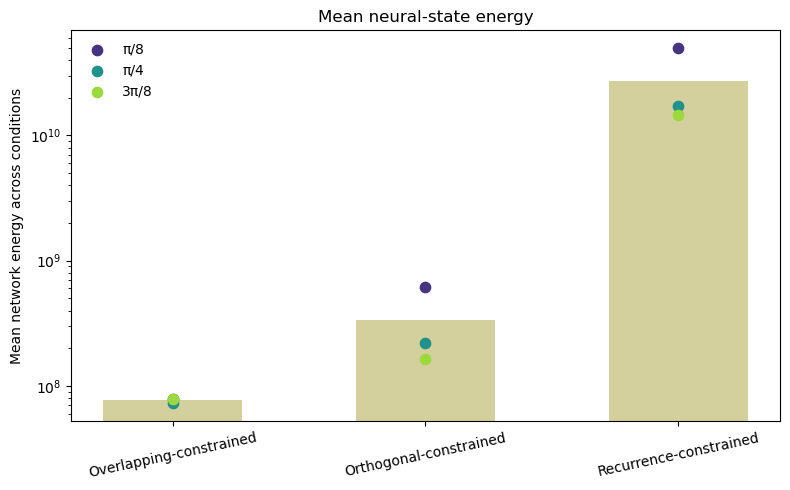

array([[7.93434629e+07, 7.30092571e+07, 7.85421756e+07],
       [6.13310176e+08, 2.21444907e+08, 1.65368858e+08],
       [4.97186736e+10, 1.70571976e+10, 1.45702474e+10]])

In [4]:
colors = plt.get_cmap("viridis")(np.linspace(0.15, 0.85, len(angle_indices)))
network_energy = np.zeros((len(controller_types), len(angle_indices)))
for controller_position, controller_name in enumerate(controller_types):
    for condition_position, condition_index in enumerate(angle_indices):
        network_energy[controller_position, condition_position] = np.sum(data[(controller_name, condition_index)] ** 2)

figure, axis = plt.subplots(figsize=(10, 5))
condition_positions = np.arange(len(angle_indices))
width = 0.24
for controller_position, controller_name in enumerate(controller_types):
    axis.bar(condition_positions + (controller_position - 1) * width, network_energy[controller_position], width=width, label=controller_labels[controller_name], alpha=0.75)
axis.set_xticks(condition_positions, [angle_labels[index] for index in angle_indices])
axis.set_xlabel("Angle condition")
axis.set_ylabel("Network energy")
axis.set_title("Neural-state energy by condition")
if np.all(network_energy > 0):
    axis.set_yscale("log")
axis.legend(frameon=False)
figure.tight_layout()
plt.show()

figure, axis = plt.subplots(figsize=(8, 5))
controller_positions = np.arange(len(controller_types))
axis.bar(controller_positions, np.mean(network_energy, axis=1), width=0.55, color="darkkhaki", alpha=0.65)
for condition_position, condition_index in enumerate(angle_indices):
    axis.scatter(controller_positions, network_energy[:, condition_position], color=colors[condition_position], s=55, label=angle_labels[condition_index], zorder=2)
axis.set_xticks(controller_positions, [controller_labels[name] for name in controller_types], rotation=12)
axis.set_ylabel("Mean network energy across conditions")
axis.set_title("Mean neural-state energy")
if np.all(network_energy > 0):
    axis.set_yscale("log")
axis.legend(frameon=False)
figure.tight_layout()
plt.show()

network_energy